In [1]:
import json
from pathlib import Path
from datetime import datetime
from typing import Optional, Tuple, Dict

#from data.minbpe import BasicTokenizer as Tokenizer
from src.minbpe import RegexTokenizer as Tokenizer
from src.gpt import GPTLanguageModel

import matplotlib.pyplot as plt
import torch
torch.manual_seed(3647)
torch.set_float32_matmul_precision('high')
import torch.nn as nn
from torch.nn import functional as F
from torch.utils.data import Dataset, DataLoader

In [2]:
def now():
    return datetime.now().astimezone().strftime('%FT%T%:z')

def print_model_structure(model: nn.Module, indent: str = '') -> None:
    """
    Custom function to print model structure in a hierarchical format
    """
    for name, child in model.named_children():
        params = sum(p.numel() for p in child.parameters())
        print(f"{indent}├─ {name}: {child.__class__.__name__} ({params:,} parameters)")
        print_model_structure(child, indent + '│  ')

class TextDataset(Dataset):
    def __init__(self, data: torch.Tensor, block_size: int) -> None:
        self.data = data
        self.block_size = block_size

    def __len__(self) -> int:
        return len(self.data) - self.block_size

    def __getitem__(self, index: int) -> Tuple[torch.Tensor, torch.Tensor]:
        x = self.data[index:index + self.block_size]
        y = self.data[index + 1:index + self.block_size + 1]
        return x, y

def get_dataloaders(
        train_data: torch.Tensor,
        val_data: torch.Tensor,
        block_size: int,
        batch_size: int,
        device: torch.device,
) -> Tuple[DataLoader, DataLoader]:
    train_dataset = TextDataset(train_data.to(device), block_size)
    val_dataset = TextDataset(val_data.to(device), block_size)

    train_loader = DataLoader(
        train_dataset,
        batch_size=batch_size,
        shuffle=True,
    )

    val_loader = DataLoader(
        val_dataset,
        batch_size=batch_size,
        shuffle=False,
    )

    return train_loader, val_loader

In [3]:
tokenizer_dir = Path("data") / "tokenizer"

tokenizer = Tokenizer()
tokenizer.load(model_file=str(tokenizer_dir / "tokenizer.model"))

train_data = torch.load(tokenizer_dir / 'train.tokens.pt')
val_data = torch.load(tokenizer_dir / 'validation.tokens.pt')

print(f"--> train_data: {train_data.size()[0]:_}, val_data: {val_data.size()[0]:_}")

--> train_data: 12_092_088, val_data: 616_680


In [4]:
#### model parameters
parameters = {
  'vocab_size': len(tokenizer.vocab),
  'n_embd': 128,
  'block_size': 512,
  'n_head': 8,
  'n_layer': 2,
  'dropout': 0.2,
}

device = 'cuda' if torch.cuda.is_available() else 'cpu'

#### training parameters
iter_start, max_iters = 1, 1000
learning_rate = 1e-4
batch_size = 128
eval_interval = 10
eval_iters = 200
save_interval = 100

model = GPTLanguageModel(
    vocab_size=parameters['vocab_size'],
    block_size=parameters['block_size'],
    n_embd=parameters['n_embd'],
    n_head=parameters['n_head'],
    n_layer=parameters['n_layer'],
    dropout=parameters['dropout'],
    device=device,
).to(device)

model = torch.compile(model)
optimizer = torch.optim.AdamW(model.parameters(), lr=learning_rate)

num_parameters = sum(p.numel() for p in model.parameters()) / 1e6
print(f'--> {num_parameters:_.3}M parameters')
# print_model_structure(model)

--> 0.726M parameters


In [5]:
checkpoint_dir = Path("data") / "ch03_checkpoints"
checkpoint_dir.mkdir(parents=True, exist_ok=True)

checkpoints = sorted(
    checkpoint_dir.glob("checkpoint_*.pt"),
    key=lambda x: x.stat().st_ctime,
    #key=lambda x: int(x.name.split("-")[1]),
    reverse=True,
)

if len(checkpoints) > 0:
    last_ckpt = torch.load(checkpoints[0], map_location=device)
    iter_start = checkpoints[0].name.replace("checkpoint_", "").replace(".pt", "").split("-", 1)[0]
    iter_start = int(iter_start) + 1
    meta = last_ckpt['meta']
    print(f"--> resume_from_checkpoint: path={checkpoints[0]}, created_at={meta['created_at']}, epoch={meta['epoch']}, iter_start={iter_start}")

    model.load_state_dict(last_ckpt['model_state_dict'])
    optimizer.load_state_dict(last_ckpt['optimizer_state_dict'])
else:
    print("No last checkpoints found")

--> resume_from_checkpoint: path=data/ch03_checkpoints/checkpoint_004000.pt, created_at=2025-09-01T12:56:16+08:00, epoch=4000, iter_start=4001


In [6]:
def get_batch(split: str) -> Tuple[torch.Tensor, torch.Tensor]:
    block_size = parameters['block_size']
    # generate a small batch of data of inputs x and targets y
    data = train_data if split == 'train' else val_data
    index = torch.randint(len(data) - block_size, (batch_size,))
    x = torch.stack([data[i:i+block_size] for i in index])
    y = torch.stack([data[i+1:i+block_size+1] for i in index])
    x, y = x.to(device), y.to(device)
    return x, y

@torch.no_grad()
def estimate_loss(eval_iters: int) -> Dict:
    output = {}
    model.eval()

    for split in ['train', 'val']:
        losses = torch.zeros(eval_iters)

        for k in range(eval_iters):
            x, y = get_batch(split)
            _, loss = model(x, y)
            losses[k] = loss.item()

        output[split] = losses.mean()

    model.train()
    return output

In [7]:
train_loader, val_loader = get_dataloaders(
    train_data=train_data,
    val_data=val_data,
    block_size=parameters['block_size'],
    batch_size=batch_size,
    device=device,
)

train_losses, val_losses = [], []

In [8]:
for iteration in range(iter_start, max_iters+1):
    if iteration % eval_interval == 0 or iteration == max_iters:
        losses = estimate_loss(eval_iters)
        print("{} step {:07_}: train_loss={:.3f}, validation_loss={:.3f}".format(
            now(), iteration, losses['train'], losses['val'],
        ))

        train_losses.append(losses['train'])
        val_losses.append(losses['val'])

    x_batch, y_batch = get_batch('train')
    logits, loss = model(x_batch, y_batch)
    optimizer.zero_grad(set_to_none=True)
    loss.backward()
    optimizer.step()

    if iteration % save_interval != 0:
        continue

    losses = estimate_loss(eval_iters)
    loss_val = loss.item()
    checkpoint_prefix = str(checkpoint_dir / f"checkpoint_{iteration:06}")
    meta = {
        'created_at': now(),
        'parameters': parameters,
        'epoch': iteration,
        'loss': loss_val,
        'train_loss': float(losses['train']),
        'validation_loss': float(losses['val']),
    }

    checkpoint = {
        'meta': meta,
        'model_state_dict': model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
    }

    with open(checkpoint_prefix + ".json", 'w', encoding='utf-8') as f:
        json.dump(meta, f, ensure_ascii=False, indent=4)

    torch.save(checkpoint, checkpoint_prefix+".pt")
    print(f"{now()} saved checkpoint: {checkpoint_prefix}.pt, loss: {loss_val:.3f}")

2025-09-01T15:16:16+08:00 step 004_010: train_loss=3.527, validation_loss=3.636
2025-09-01T15:16:34+08:00 step 004_020: train_loss=3.528, validation_loss=3.631
2025-09-01T15:16:51+08:00 step 004_030: train_loss=3.525, validation_loss=3.627
2025-09-01T15:17:08+08:00 step 004_040: train_loss=3.524, validation_loss=3.627
2025-09-01T15:17:26+08:00 step 004_050: train_loss=3.527, validation_loss=3.628
2025-09-01T15:17:43+08:00 step 004_060: train_loss=3.523, validation_loss=3.628
2025-09-01T15:18:00+08:00 step 004_070: train_loss=3.519, validation_loss=3.624
2025-09-01T15:18:18+08:00 step 004_080: train_loss=3.515, validation_loss=3.620
2025-09-01T15:18:35+08:00 step 004_090: train_loss=3.518, validation_loss=3.618
2025-09-01T15:18:52+08:00 step 004_100: train_loss=3.517, validation_loss=3.616
2025-09-01T15:19:09+08:00 saved checkpoint: data/ch03_checkpoints/checkpoint_004100.pt, loss: 3.735
2025-09-01T15:19:26+08:00 step 004_110: train_loss=3.512, validation_loss=3.614
2025-09-01T15:19:43+

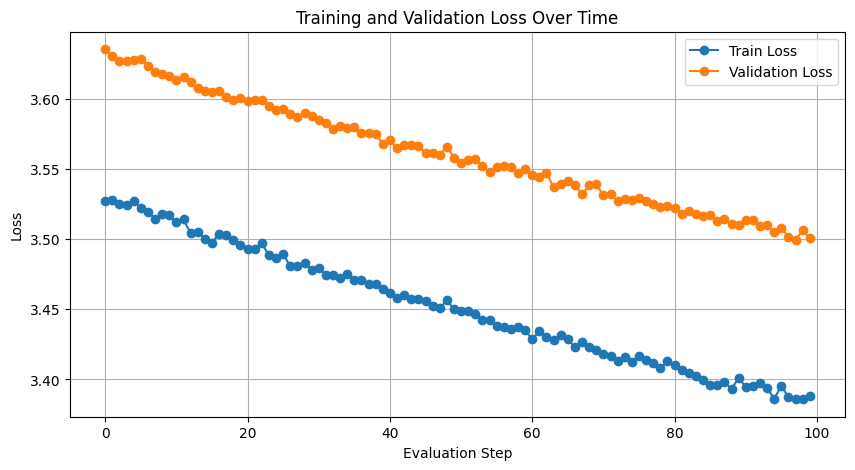

In [10]:
plt.figure(figsize=(10, 5))
plt.plot(train_losses, label="Train Loss", marker='o')
plt.plot(val_losses, label="Validation Loss", marker='o')
plt.xlabel("Evaluation Step")
plt.ylabel("Loss")
plt.title("Training and Validation Loss Over Time")
plt.legend()
plt.grid()
plt.show()

# 001_000: train_loss=4.38, validation_loss=4.41
# 003_000: train_loss=3.75, validation_loss=3.82
# 005_000: train_loss=3.37, validation_loss=3.47
# 010_000: train_loss=3.08, validation_loss=3.21
# 015_000: train_loss=None, validation_loss=None

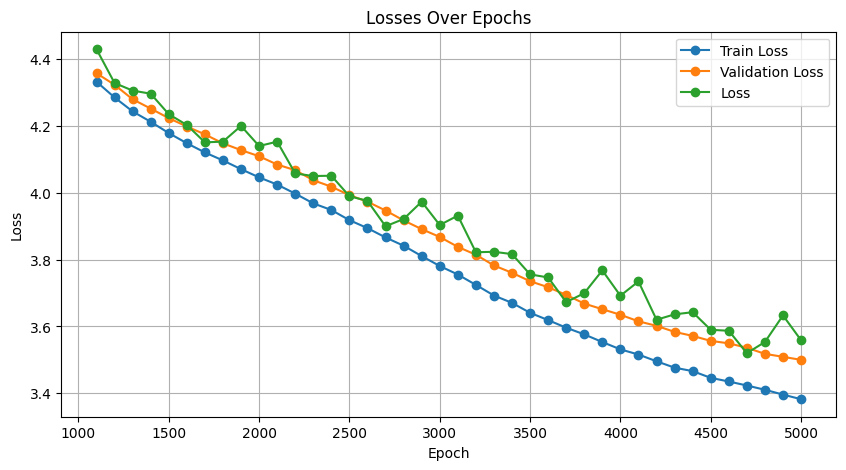

In [9]:
# checkpoint_dir = Path("data") / "ch03_checkpoints"
json_files = sorted(
    checkpoint_dir.glob("*.json"),
    key=lambda x: x.stat().st_ctime,
    #key=lambda x: int(x.name.split("-")[1]),
    reverse=False,
)

epochs, losses, train_loss, val_loss = [], [], [], []

for f in json_files:
    #print(f"---> file: {f}")
    data = json.loads(f.read_text())
    losses.append(data['loss'])
    epochs.append(data['epoch'])
    train_loss.append(data['train_loss'])
    val_loss.append(data['validation_loss'])

plt.figure(figsize=(10, 5))
plt.plot(epochs, train_loss, label="Train Loss", marker='o')
plt.plot(epochs, val_loss, label="Validation Loss", marker='o')
plt.plot(epochs, losses, label="Loss", marker='o')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Losses Over Epochs")
plt.legend()
plt.grid()
plt.show()